# 1. Install Required Libraries

In [1]:
pip install pandas scikit-learn matplotlib seaborn xgboost

Note: you may need to restart the kernel to use updated packages.


# 2 Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 3 Load Dataset

In [3]:
df = pd.read_csv("covtype.csv")

print(df.head())
print(df.shape)
print(df.info())

   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234             238   

# 4 Check Missing Values

In [4]:
print(df.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


# 5 Separate Features and Target

In [20]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"] - 1

# 6 Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 7 Random Forest Model

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9551646687262807


# 8 Classification Report

In [23]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95     42557
           1       0.95      0.97      0.96     56500
           2       0.94      0.96      0.95      7121
           3       0.91      0.85      0.88       526
           4       0.94      0.77      0.85      1995
           5       0.93      0.90      0.92      3489
           6       0.97      0.96      0.97      4015

    accuracy                           0.96    116203
   macro avg       0.95      0.91      0.93    116203
weighted avg       0.96      0.96      0.95    116203



# 9 Confusion Matrix Visualization

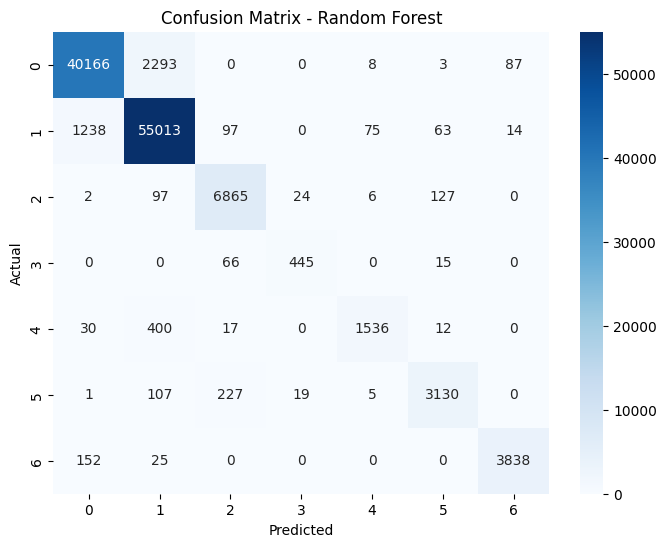

In [24]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

# 10 Feature Importance

In [25]:
importances = rf.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df.head(10))

                              Feature  Importance
0                           Elevation    0.240912
5     Horizontal_Distance_To_Roadways    0.118431
9  Horizontal_Distance_To_Fire_Points    0.111732
3    Horizontal_Distance_To_Hydrology    0.061013
4      Vertical_Distance_To_Hydrology    0.057475
1                              Aspect    0.047829
7                      Hillshade_Noon    0.042941
6                       Hillshade_9am    0.041357
8                       Hillshade_3pm    0.040920
2                               Slope    0.032988


# Feature Importance Plot

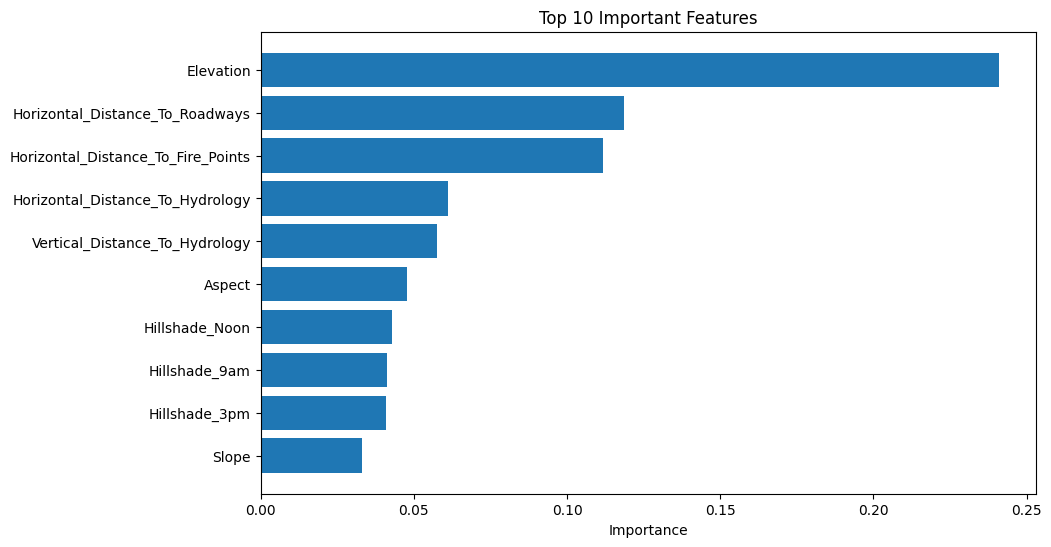

In [26]:
plt.figure(figsize=(10,6))

plt.barh(importance_df['Feature'][:10], importance_df['Importance'][:10])

plt.xlabel("Importance")
plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# 12 XGBoost Model

In [29]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))         


XGBoost Accuracy: 0.869925905527396


# 13 Confusion Matrix for XGBoost

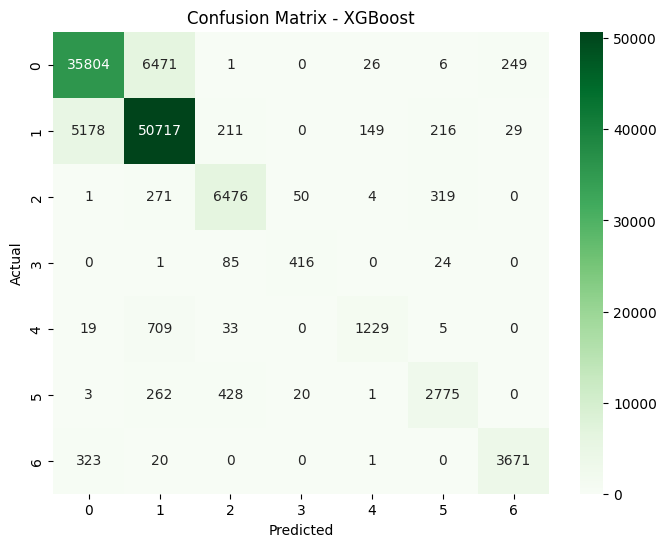

In [30]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8,6))

sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")

plt.show()

# 14 Model Comparison

In [31]:
rf_acc = accuracy_score(y_test, y_pred_rf)
xgb_acc = accuracy_score(y_test, y_pred_xgb)

print("Random Forest Accuracy:", rf_acc)
print("XGBoost Accuracy:", xgb_acc)

Random Forest Accuracy: 0.9551646687262807
XGBoost Accuracy: 0.869925905527396


# 15 Hyperparameter Tuning

In [32]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [10,20,None],
    'min_samples_split': [2,5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [33]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_best))

Tuned Random Forest Accuracy: 0.955775668442295
